## SETUP 

In [1]:
## SETUP

import subprocess, sys, os, importlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pca_main_functions
from sklearn.decomposition import PCA

from pca_obtain_energy_range import find_common_energy_range
import pca_interpolate_DOS

importlib.reload(pca_main_functions)
importlib.reload(pca_interpolate_DOS)


<module 'pca_interpolate_DOS' from 'c:\\Users\\jespe\\Desktop\\[THESIS] Code\\-ESPEJO-THESIS-DOS-ML-Model-\\SCRIPTS_PCA\\pca_interpolate_DOS.py'>

In [2]:
def overall_pca(results_dir, doscar_dir, dataset):

    energy_ranges = [find_common_energy_range(doscar_dir), (-5.0, 5.0), (-10.0, 10.0)]

    # Initialize an empty list to store results
    results = []

    for range in energy_ranges:
        min_energy_global = range[0]
        max_energy_global = range[1]

        pca_interpolate_DOS.interpolate_all(doscar_dir, min_energy_global, max_energy_global)

        interpolated_filepath = os.path.join(doscar_dir,f'interpolated_dos_[{min_energy_global:.2f},{max_energy_global:.2f}].txt')

        molecule_names, dos_data = pca_main_functions.load_interpolated_dos(interpolated_filepath)
        
        np.savetxt('molecule_names.txt', molecule_names, fmt='%s')

        energy_values = dos_data.iloc[0,1:]
        dos_samples = dos_data.iloc[1:,:]
        pca, scaled_data = pca_main_functions.perform_PCA(dos_samples)

        explained_variance = pca.explained_variance_ratio_
        cumulative_variance = np.cumsum(explained_variance)

        thresholds = [0.80, 0.90]

        for threshold in thresholds:
            n_pc = np.argmax(cumulative_variance >= threshold) + 1
            pca_main_functions.transform_data_to_pc(results_dir, dataset, molecule_names, scaled_data, 
                                                    min_energy_global, max_energy_global, 
                                                    threshold, n_pc)

            # Store the results for this energy range and threshold
            results.append({
                'dataset': dataset,
                'min_energy': min_energy_global,
                'max_energy': max_energy_global,
                'energy_range': f'({min_energy_global:.2f}, {max_energy_global:.2f})',
                'cum_variance': threshold,  # Cumulative variance at the end
                'n_pc': n_pc
            })

    # Convert the results list to a pandas DataFrame
    results_df = pd.DataFrame(results)

    # Save results in overall results excel
    excel_name = os.path.join(results_dir, 'overall_results.xlsx')

    sheet_name = f'pca_results'

    # Save to Excel (append if file already exists)
    if os.path.exists(excel_name):
        # If Excel file does not exists, create a new Excel file
        with pd.ExcelWriter(excel_name, mode="a", engine="openpyxl", if_sheet_exists="replace") as writer:
            results_df.to_excel(writer, sheet_name=sheet_name, index=False) 
    else:
        with pd.ExcelWriter(excel_name) as writer:
            results_df.to_excel(writer, sheet_name=sheet_name, index=False) 

    return results_df

In [3]:
# Create an empty DataFrame
overall_results = pd.DataFrame(columns=['dataset',
                                        'energy_range',
                                        'cum_variance',
                                        'n_pc'], dtype='float64')

overall_results

,dataset,energy_range,cum_variance,n_pc


In [4]:
base_dir = os.path.dirname(os.getcwd())
results_dir =  os.path.join(base_dir, 'RESULTS')

doscar_files_dirs = [f for f in os.listdir(base_dir) if f.startswith('DOSCAR_Files')]

for dir in doscar_files_dirs:
    #print(f"Processing directory is {dir}")
    dir_path = os.path.join(base_dir, dir)
    cur_results = overall_pca(results_dir, dir_path, dir)
    overall_results = pd.concat([overall_results, cur_results], ignore_index=True).drop_duplicates()

overall_results


c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\SCRIPTS_PCA\pca_main_functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filepath, delim_whitespace=True, header=None)
c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\SCRIPTS_PCA\pca_main_functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filepath, delim_whitespace=True, header=None)
c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\SCRIPTS_PCA\pca_main_functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filepath, delim_whitespace=True, header=None)
c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Mo

,dataset,energy_range,cum_variance,n_pc,min_energy,max_energy
0,DOSCAR_Files,"(-1.46, 3.27)",0.8,2.0,-1.464443,3.267161
1,DOSCAR_Files,"(-1.46, 3.27)",0.9,5.0,-1.464443,3.267161
2,DOSCAR_Files,"(-5.00, 5.00)",0.8,13.0,-5.000000,5.000000
3,DOSCAR_Files,"(-5.00, 5.00)",0.9,23.0,-5.000000,5.000000
4,DOSCAR_Files,"(-10.00, 10.00)",0.8,19.0,-10.000000,10.000000
5,DOSCAR_Files,"(-10.00, 10.00)",0.9,36.0,-10.000000,10.000000
6,DOSCAR_Files_Initial,"(-16.14, 4.12)",0.8,25.0,-16.136248,4.121110
7,DOSCAR_Files_Initial,"(-16.14, 4.12)",0.9,34.0,-16.136248,4.121110
8,DOSCAR_Files_Initial,"(-5.00, 5.00)",0.8,16.0,-5.000000,5.000000
9,DOSCAR_Files_Initial,"(-5.00, 5.00)",0.9,22.0,-5.000000,5.000000


In [5]:
# Create a combined 'hue_style' column to combine both cum_variance and energy_range
overall_results['hue_style'] = 'Variance: ' + overall_results['cum_variance'].astype(str) + ' \n Energy range: ' + overall_results['energy_range'].astype(str)

overall_results

,dataset,energy_range,cum_variance,n_pc,min_energy,max_energy,hue_style
0,DOSCAR_Files,"(-1.46, 3.27)",0.8,2.0,-1.464443,3.267161,"Variance: 0.8 \n Energy range: (-1.46, 3.27)"
1,DOSCAR_Files,"(-1.46, 3.27)",0.9,5.0,-1.464443,3.267161,"Variance: 0.9 \n Energy range: (-1.46, 3.27)"
2,DOSCAR_Files,"(-5.00, 5.00)",0.8,13.0,-5.000000,5.000000,"Variance: 0.8 \n Energy range: (-5.00, 5.00)"
3,DOSCAR_Files,"(-5.00, 5.00)",0.9,23.0,-5.000000,5.000000,"Variance: 0.9 \n Energy range: (-5.00, 5.00)"
4,DOSCAR_Files,"(-10.00, 10.00)",0.8,19.0,-10.000000,10.000000,"Variance: 0.8 \n Energy range: (-10.00, 10.00)"
5,DOSCAR_Files,"(-10.00, 10.00)",0.9,36.0,-10.000000,10.000000,"Variance: 0.9 \n Energy range: (-10.00, 10.00)"
6,DOSCAR_Files_Initial,"(-16.14, 4.12)",0.8,25.0,-16.136248,4.121110,"Variance: 0.8 \n Energy range: (-16.14, 4.12)"
7,DOSCAR_Files_Initial,"(-16.14, 4.12)",0.9,34.0,-16.136248,4.121110,"Variance: 0.9 \n Energy range: (-16.14, 4.12)"
8,DOSCAR_Files_Initial,"(-5.00, 5.00)",0.8,16.0,-5.000000,5.000000,"Variance: 0.8 \n Energy range: (-5.00, 5.00)"
9,DOSCAR_Files_Initial,"(-5.00, 5.00)",0.9,22.0,-5.000000,5.000000,"Variance: 0.9 \n Energy range: (-5.00, 5.00)"


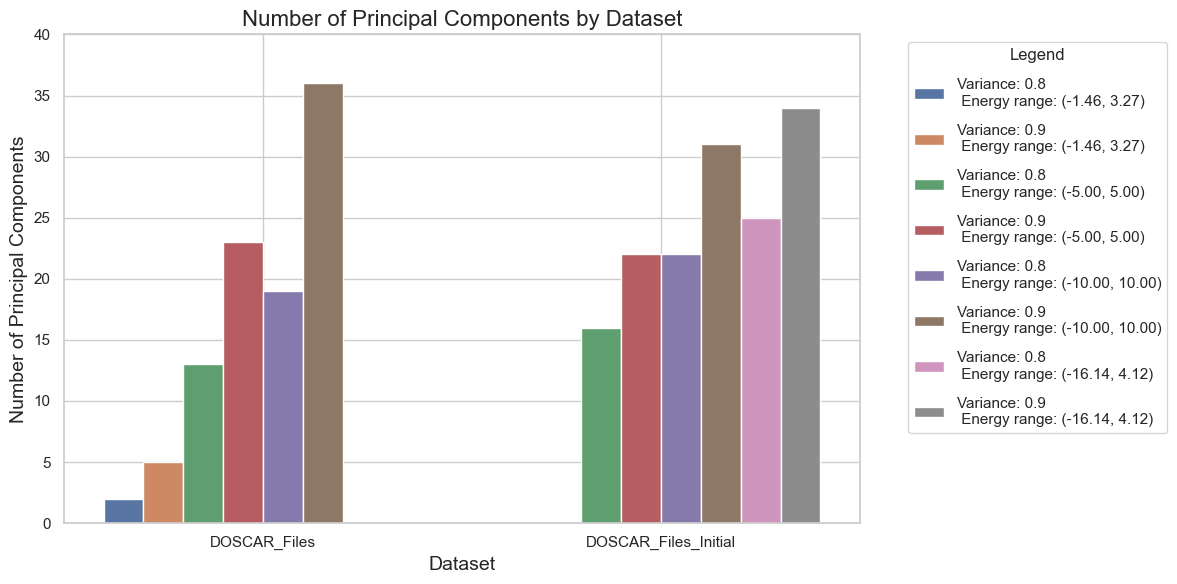

In [25]:
# Create a combined 'hue_style' column to combine both cum_variance and energy_range
overall_results['hue_style'] = 'Variance: ' + overall_results['cum_variance'].astype(str) + ' \n Energy range: ' + overall_results['energy_range'].astype(str)

# Set the style for the plot
sns.set(style="whitegrid")

# Create a scatter plot
plt.figure(figsize=(12, 6))
# sns.scatterplot(data=overall_results, x='dataset', y='n_pc', hue='hue_style', style='hue_style', s=100)
sns.barplot(data=overall_results, x='dataset', y='n_pc', hue='hue_style', dodge=True)

# Add titles and labels
plt.title('Number of Principal Components by Dataset', fontsize=16)
plt.xlabel('Dataset', fontsize=14)
plt.ylabel('Number of Principal Components', fontsize=14)
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), labelspacing=1.0, loc='upper left')
plt.grid(True)

# Adjust y-axis ticks if necessary
plt.yticks(range(0, int(overall_results['n_pc'].max()) + 5, 5))

# Show the plot
plt.tight_layout()
plt.show()


## Explained Variance Ratio
how much of the original data’s variance is captured by each principal component. It helps in understanding the importance of each component

Total variance explained by each principal component (PC): Indicate how much of the variation in your dataset is captured by each PC. This helps justify how many components should be kept for downstream analysis.
- USE BAR GRAPH

Cumulative variance: If, for example, the first few PCs explain 95% of the variance, it shows that you can reduce the dimensionality significantly without losing much information.
- USE STEP GRAPH

In [6]:
base_dir=os.path.join(os.path.dirname(os.getcwd()), 'DOSCAR_Files')

min_energy = -5.0
max_energy = 5.0

interpolated_filepath = os.path.join(base_dir,f'interpolated_dos_[{min_energy:.2f},{max_energy:.2f}].txt')

molecule_names, dos_data = pca_main_functions.load_interpolated_dos(interpolated_filepath)

energy_values = dos_data.iloc[0,1:]
dos_samples = dos_data.iloc[1:,:]

pca, scaled_data = pca_main_functions.perform_PCA(dos_samples)
principal_components = pca.fit_transform(scaled_data)

np.savetxt('molecule_names.txt', molecule_names, fmt='%s')

c:\Users\jespe\Desktop\[THESIS] Code\-ESPEJO-THESIS-DOS-ML-Model-\SCRIPTS_PCA\pca_main_functions.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filepath, delim_whitespace=True, header=None)


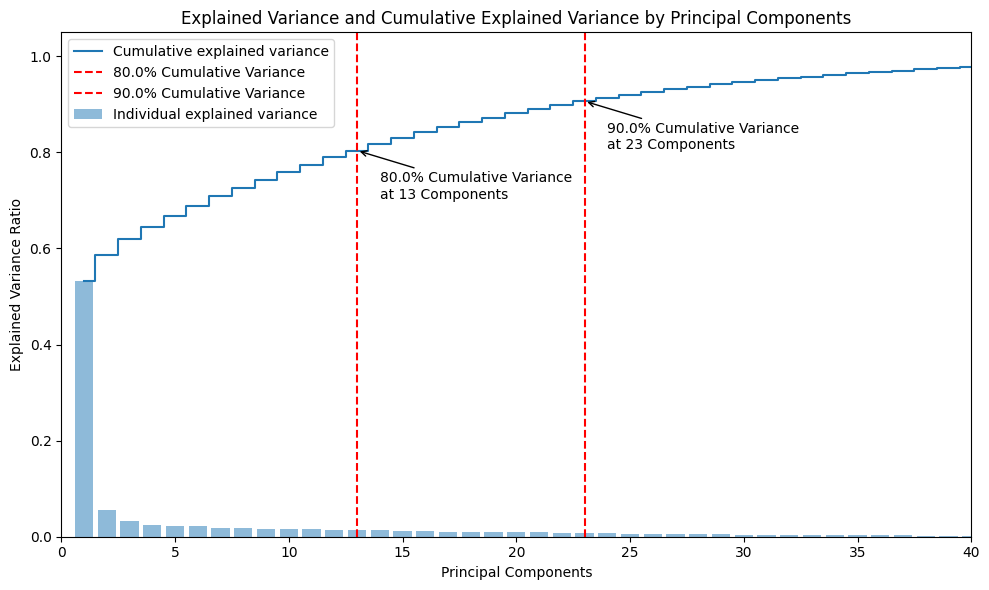

In [7]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
# print(f"The explained variance is {explained_variance}")

# Plotting the explained variance and cumulative variance
plt.figure(figsize=(10,6))

# Plotting explained variance
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, align='center', label='Individual explained variance')

# Plotting cumulative variance
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative explained variance')

# Find the number of components needed for 90% cumulative variance
thresholds = [0.80, 0.90]

for threshold in thresholds:
    num_components_threshold = np.argmax(cumulative_variance >= threshold) + 1
    # Adding a vertical line at the 90% cumulative variance point
    plt.axvline(x=num_components_threshold, color='r', linestyle='--', label=f'{threshold*100}% Cumulative Variance')

    # Annotating the line
    plt.annotate(f'{threshold*100}% Cumulative Variance\nat {num_components_threshold} Components',
                xy=(num_components_threshold, cumulative_variance[num_components_threshold - 1]),
                xytext=(num_components_threshold + 1, cumulative_variance[num_components_threshold - 1] - 0.1),
                arrowprops=dict(facecolor='black', arrowstyle='->'),
                fontsize=10)

# Set x-axis limit
plt.xlim(0, 40)

# Adding labels and titles
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance and Cumulative Explained Variance by Principal Components')
plt.legend(loc='best')
plt.tight_layout()

# Show the plot
plt.show()

## Principal Components Interpretation

**Loading Scores**
- See which features (DOS data columns contribute most to each PC)
- Provides insight into which orbitals or energy ranges are influencing the variance

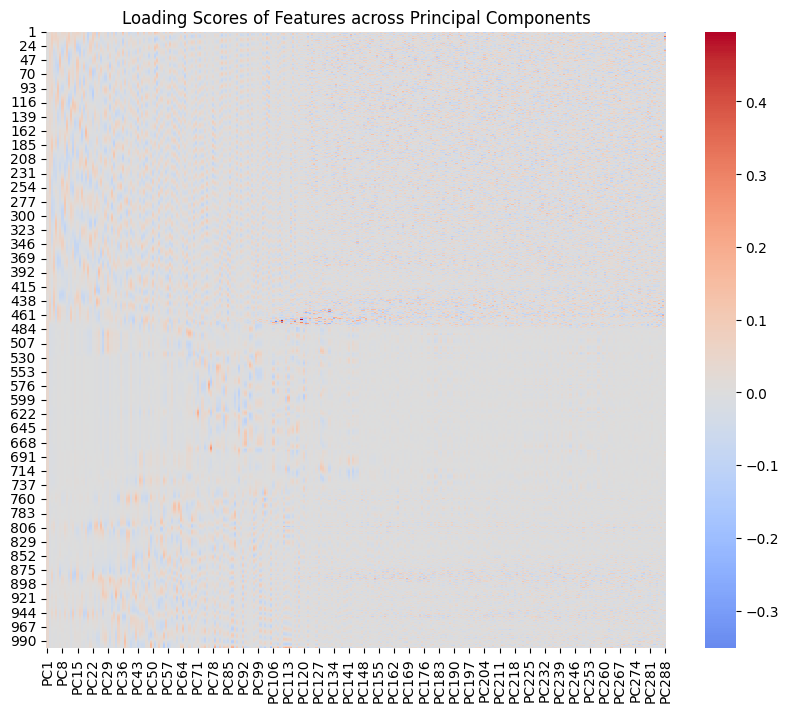

In [8]:
# Loading Scores (principal component coefficients)
# The components_ attribute contains the loading scores
loading_scores = pd.DataFrame(pca.components_.T, 
                              index=dos_data.columns, 
                              columns=[f'PC{i+1}' for i in range(len(pca.components_))])

# loading_scores.to_csv('loading_scores.txt', sep='\t', index=False)

"""
# Display the loading scores for each PC
print ("Loading Scores (Principal Component Coefficients):")
loading_scores
"""

# Visualizing all loading scores using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(loading_scores, cmap='coolwarm', center=0)
plt.title('Loading Scores of Features across Principal Components')
plt.show()